# Bayesian Optimization for Enhanced Tire Compound Durability and Efficiency

This notebook uses Bayesian Optimization to enhance durability of tires, an important factor in commuter cars as well as endurance racers where tires must balance performance with longevity. BO is used to minimize wear (abrasion) and heat generation (rolling resistance) that leads to excessive wear.

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process.kernels import RationalQuadratic

In [107]:
param_names = ["v_time", "v_temp", "x_s", "x_cb", "mix", "grade"]
param_bounds = np.array([[300, 1000], [403, 453], [1, 10], [1, 35], [1, 11], [1, 100]])
integer_params = [0, 1, 2, 3, 4, 5]
output_names = ["material_cost", "heating_cost", "mixing_cost", "sound_damping", "rolling_resistance", "abrasion", "dry_grip", "wet_grip"]

scaler = MinMaxScaler()
scaler.fit(param_bounds.T)

def UCB(mean, std, beta=1.0):
    return mean + beta*std

def PI(mean, std, c=1.5):
    z = (mean.max() * c - mean) / std
    return 1-norm.cdf(z)

def EI(mean, std):
    d = mean - mean.max()
    z = -d / std
    return d*(1-norm.cdf(z)) + std*norm.pdf(z)

def NextPoint(gp, X_train, y_train, n_candidates=50000, seed=None): 
    # The 'candidates' are randomly sampled points across the 6D parameter space.
        # Trained GP predicts mean and std at each candidate --> scored by EI to find next experiment to run.
    rng = np.random.default_rng(seed)
    gp.fit(scaler.transform(X_train.T), y_train)
    
    X_cand = np.zeros((6, n_candidates))
    for i in range(6): X_cand[i] = rng.uniform(param_bounds[i, 0], param_bounds[i, 1], n_candidates)
    for idx in integer_params: X_cand[idx] = np.round(X_cand[idx]).clip(param_bounds[idx, 0], param_bounds[idx, 1])
    
    y_pred, y_std = gp.predict(scaler.transform(X_cand.T), return_std=True)
    
    ei_vals = EI(y_pred, y_std)
    i_next = np.argmax(ei_vals)
    x_next = X_cand[:, i_next]
    
    return x_next

## Initialization Data (The first 5 Points)

In [3]:
X_train = np.array([
    [650, 428, 5, 18, 6, 50],
    [750, 447, 7, 24, 5, 70],
    [458, 415, 3, 10, 2, 32],
    [899, 405, 1, 32, 8, 91],
    [377, 435, 9,  2, 11, 5]], dtype=float).T

results = [
    {"material_cost": 652.32347, "heating_cost": 11.875, "mixing_cost": 29.1222,
     "sound_damping": 0.08635321149188717, "rolling_resistance": 0.1772650074126504,
     "abrasion": 343.1309573700778, "dry_grip": 0.00305106876599966, "wet_grip": 4.79231477},

    {"material_cost": 1047.667708, "heating_cost": 15.120000000000001, "mixing_cost": 24.2685,
     "sound_damping": 0.06799501536549545, "rolling_resistance": 0.14040888545605992,
     "abrasion": 272.4793710784738, "dry_grip": 0.001745032386087494, "wet_grip": 7.04167872},

    {"material_cost": 364.45193199999994, "heating_cost": 8.489600000000001, "mixing_cost": 9.7074,
     "sound_damping": 0.13081222478416077, "rolling_resistance": 0.3102083267734656,
     "abrasion": 428.94298432566035, "dry_grip": 0.007346797785537304, "wet_grip": 1.584387198},

    {"material_cost": 1650.0819032, "heating_cost": 12.229800000000001, "mixing_cost": 38.8296,
     "sound_damping": 0.07903992534389295, "rolling_resistance": 0.23287878215460714,
     "abrasion": 241.6363501179152, "dry_grip": 0.009752820430088745, "wet_grip": 8.90681416},

    {"material_cost": 237.91522099999997, "heating_cost": 8.9364, "mixing_cost": 53.390699999999995,
     "sound_damping": 0.11211089049998915, "rolling_resistance": 0.15593618360022096,
     "abrasion": 5794.259219712325, "dry_grip": 0.0007438244399266374, "wet_grip": 0.876630396}
]

n_init = X_train.shape[1]
all_outputs = {name: np.array([r[name] for r in results]) for name in output_names}

print("Initial data:")
for i in range(n_init):
    print(f"  Point {i+1}: abrasion={results[i]['abrasion']:.2f}, "
          f"rolling_res={results[i]['rolling_resistance']:.6f}, "
          f"dry_grip={results[i]['dry_grip']:.6f}")

Initial data:
  Point 1: abrasion=343.13, rolling_res=0.177265, dry_grip=0.003051
  Point 2: abrasion=272.48, rolling_res=0.140409, dry_grip=0.001745
  Point 3: abrasion=428.94, rolling_res=0.310208, dry_grip=0.007347
  Point 4: abrasion=241.64, rolling_res=0.232879, dry_grip=0.009753
  Point 5: abrasion=5794.26, rolling_res=0.155936, dry_grip=0.000744


---
## Optimization #1: Abrasion Minimization

The goal of the following Bayesian Optimization is to develop a new set of features for the tire fabrication method, that minimizes abrasion (increases longevity and durability of the tire). 


Process: Initialize --> negate (abrasion must be minimized) --> fit GP --> generate 50,000 candidate points --> score using EI --> run experiment --> append and repeat until 20 iterations

In [ ]:
gp_abrasion = GaussianProcessRegressor(kernel=RationalQuadratic())

X_train_A = X_train.copy()
y_train_A = -all_outputs["abrasion"].copy()  # negated
all_outputs_A = {name: all_outputs[name].copy() for name in output_names}

i_best = np.argmax(y_train_A)
print(f"Current best abrasion: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

Current best abrasion: 241.6364 (Point 4)


### Opt1: Iteration #1

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=6)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 677
---v_temp: 450
---x_s: 3
---x_cb: 6
---mix: 10
---grade: 72


c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
new_Abrasion_Iter1 = {
    "material_cost": 430.7501352,
    "heating_cost": 14.361900000000002,
    "mixing_cost": 48.537,
    "sound_damping": 0.11276532534474222,
    "rolling_resistance": 0.23451200888843493,
    "abrasion": 428.94298432566035,
    "dry_grip": 0.004568967954451768,
    "wet_grip": 2.28637837
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter1["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter1[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter1['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 428.9430
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #2

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=7)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 738
---v_temp: 422
---x_s: 7
---x_cb: 24
---mix: 1
---grade: 96


c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
new_Abrasion_Iter2 = {
    "material_cost": 1369.7366344,
    "heating_cost": 12.3522,
    "mixing_cost": 4.8537,
    "sound_damping": 0.06643378585973458,
    "rolling_resistance": 0.1469284344692145,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0021001776400462182,
    "wet_grip": 7.58894205
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter2["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter2[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter2['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 272.4794
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #3

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=8)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 529
---v_temp: 421
---x_s: 3
---x_cb: 14
---mix: 11
---grade: 79


c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
new_Abrasion_Iter3 = {
    "material_cost": 761.6439465999999,
    "heating_cost": 9.7822,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.09082313725351351,
    "rolling_resistance": 0.2274941725540011,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.0070476822868834835,
    "wet_grip": 4.90280673
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter3["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter3[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter3['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #4

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=9)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 909
---v_temp: 435
---x_s: 9
---x_cb: 33
---mix: 2
---grade: 21


c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
new_Abrasion_Iter4 = {
    "material_cost": 524.6312373,
    "heating_cost": 15.9588,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07596875587301481,
    "rolling_resistance": 0.11893139879067634,
    "abrasion": 670.8997908072586,
    "dry_grip": 0.0007832441316294921,
    "wet_grip": 5.03772453
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter4["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter4[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter4['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 670.8998
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #5

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=10)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 969
---v_temp: 445
---x_s: 2
---x_cb: 34
---mix: 6
---grade: 45


c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
new_Abrasion_Iter5 = {
    "material_cost": 935.2835930000001,
    "heating_cost": 18.019800000000004,
    "mixing_cost": 29.1222,
    "sound_damping": 0.08104472798760967,
    "rolling_resistance": 0.21494608526295128,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.006010715254637283,
    "wet_grip": 7.947625820000001
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter5["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter5[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter5['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #6

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=11)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 390
---v_temp: 429
---x_s: 7
---x_cb: 8
---mix: 5
---grade: 19


c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
new_Abrasion_Iter6 = {
    "material_cost": 292.9755872,
    "heating_cost": 8.694,
    "mixing_cost": 24.2685,
    "sound_damping": 0.11742190393672483,
    "rolling_resistance": 0.1903211401292849,
    "abrasion": 670.8997908072586,
    "dry_grip": 0.001568342918092106,
    "wet_grip": 1.265845895
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter6["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter6[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter6['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 670.8998
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #7

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=12)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 945
---v_temp: 422
---x_s: 2
---x_cb: 32
---mix: 1
---grade: 96


In [ ]:
new_Abrasion_Iter7 = {
    "material_cost": 1735.4109392,
    "heating_cost": 14.8155,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07575127707831106,
    "rolling_resistance": 0.20774790402301493,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.006407631189896646,
    "wet_grip": 8.74729663
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter7["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter7[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter7['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #8

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=13)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 980
---v_temp: 425
---x_s: 2
---x_cb: 34
---mix: 1
---grade: 98


In [ ]:
new_Abrasion_Iter8 = {
    "material_cost": 1865.3608452,
    "heating_cost": 15.616,
    "mixing_cost": 4.8537,
    "sound_damping": 0.0753614424263767,
    "rolling_resistance": 0.20649505355791414,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.0061090717058532315,
    "wet_grip": 9.08963651
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter8["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter8[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter8['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #9

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=14)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 958
---v_temp: 413
---x_s: 1
---x_cb: 31
---mix: 1
---grade: 100


In [ ]:
new_Abrasion_Iter9 = {
    "material_cost": 1749.23823,
    "heating_cost": 13.838,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07914484809324324,
    "rolling_resistance": 0.23187102507478213,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009854364549192363,
    "wet_grip": 8.55475395
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter9["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter9[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter9['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #10

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=15)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 990
---v_temp: 435
---x_s: 2
---x_cb: 35
---mix: 2
---grade: 98


In [ ]:
new_Abrasion_Iter10 = {
    "material_cost": 1913.819443,
    "heating_cost": 17.028,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07526209360105596,
    "rolling_resistance": 0.20547520059567695,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.005913260400354733,
    "wet_grip": 9.17774409
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter10["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter10[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter10['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #11

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=16)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 966
---v_temp: 409
---x_s: 1
---x_cb: 32
---mix: 2
---grade: 89


In [ ]:
new_Abrasion_Iter11 = {
    "material_cost": 1617.0491928,
    "heating_cost": 13.419600000000003,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07894363172229349,
    "rolling_resistance": 0.23164335946366404,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.00944804654987091,
    "wet_grip": 8.94469976
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter11["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter11[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter11['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #12

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=17)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 987
---v_temp: 406
---x_s: 1
---x_cb: 35
---mix: 1
---grade: 92


In [ ]:
new_Abrasion_Iter12 = {
    "material_cost": 1802.6836019999998,
    "heating_cost": 13.256100000000002,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07901013176281473,
    "rolling_resistance": 0.2319623711360383,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009330090268368556,
    "wet_grip": 9.12036568
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter12["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter12[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter12['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #13

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=18)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 988
---v_temp: 405
---x_s: 1
---x_cb: 34
---mix: 7
---grade: 99


In [ ]:
new_Abrasion_Iter13 = {
    "material_cost": 1880.1622125999997,
    "heating_cost": 13.137599999999999,
    "mixing_cost": 33.975899999999996,
    "sound_damping": 0.07868254400457834,
    "rolling_resistance": 0.23104460297080243,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009372939293067725,
    "wet_grip": 9.12666499
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter13["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter13[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter13['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #14

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=19)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 954
---v_temp: 406
---x_s: 1
---x_cb: 35
---mix: 1
---grade: 85


In [ ]:
new_Abrasion_Iter14 = {
    "material_cost": 1676.2302574999999,
    "heating_cost": 12.916200000000002,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07892372766587666,
    "rolling_resistance": 0.23188471039412986,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009358594056256695,
    "wet_grip": 9.17999149
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter14["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter14[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter14['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #15

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=20)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 847
---v_temp: 404
---x_s: 1
---x_cb: 30
---mix: 1
---grade: 98


In [ ]:
new_Abrasion_Iter15 = {
    "material_cost": 1668.779194,
    "heating_cost": 11.584700000000002,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07929063303298851,
    "rolling_resistance": 0.2339608992855969,
    "abrasion": 231.92712082927628,
    "dry_grip": 0.010290840265059862,
    "wet_grip": 8.565411860000001
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter15["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter15[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter15['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 231.9271
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #16

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=21)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 778
---v_temp: 408
---x_s: 1
---x_cb: 30
---mix: 1
---grade: 98


In [ ]:
new_Abrasion_Iter16 = {
    "material_cost": 1668.779194,
    "heating_cost": 11.319,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07983829593905592,
    "rolling_resistance": 0.23583258581945254,
    "abrasion": 231.92712082927628,
    "dry_grip": 0.010477579188801985,
    "wet_grip": 8.40342284
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter16["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter16[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter16['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 231.9271
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #17

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=22)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 985
---v_temp: 405
---x_s: 1
---x_cb: 31
---mix: 1
---grade: 89


In [ ]:
new_Abrasion_Iter17 = {
    "material_cost": 1573.2358199,
    "heating_cost": 13.107000000000001,
    "mixing_cost": 4.8537,
    "sound_damping": 0.0793481604292217,
    "rolling_resistance": 0.23301045193663303,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009923813821337139,
    "wet_grip": 8.59438151
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter17["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter17[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter17['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #18

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=23)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 954
---v_temp: 406
---x_s: 1
---x_cb: 34
---mix: 2
---grade: 95


In [ ]:
new_Abrasion_Iter18 = {
    "material_cost": 1809.967703,
    "heating_cost": 12.916200000000002,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07884905263448369,
    "rolling_resistance": 0.2316651273629593,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.00939152268895878,
    "wet_grip": 9.14696306
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter18["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter18[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter18['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #19

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=24)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 856
---v_temp: 407
---x_s: 1
---x_cb: 34
---mix: 3
---grade: 93


In [ ]:
new_Abrasion_Iter19 = {
    "material_cost": 1774.8704482,
    "heating_cost": 12.022400000000001,
    "mixing_cost": 14.5611,
    "sound_damping": 0.07906966202999283,
    "rolling_resistance": 0.2329607311164296,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009480131676323353,
    "wet_grip": 9.1572839
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter19["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter19[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter19['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #20

In [ ]:
x_next_A = NextPoint(gp_abrasion, X_train_A, y_train_A, seed=25)
print("New parameter set:")
for name, val in zip(param_names, x_next_A): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 984
---v_temp: 404
---x_s: 1
---x_cb: 32
---mix: 2
---grade: 98


In [ ]:
new_Abrasion_Iter20 = {
    "material_cost": 1765.6963896,
    "heating_cost": 12.9684,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07972245854648292,
    "rolling_resistance": 0.2340269893223065,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009923918854606256,
    "wet_grip": 8.57515484
}

X_train_A = np.append(X_train_A, x_next_A.reshape(6, 1), axis=-1)
y_train_A = np.append(y_train_A, -new_Abrasion_Iter20["abrasion"])
for name in output_names: all_outputs_A[name] = np.append(all_outputs_A[name], new_Abrasion_Iter20[name])

i_best = np.argmax(y_train_A)
print(f"New abrasion value: {new_Abrasion_Iter20['abrasion']:.4f}")
print(f"Current best abrasion value: {-y_train_A[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


## PLOTTING:

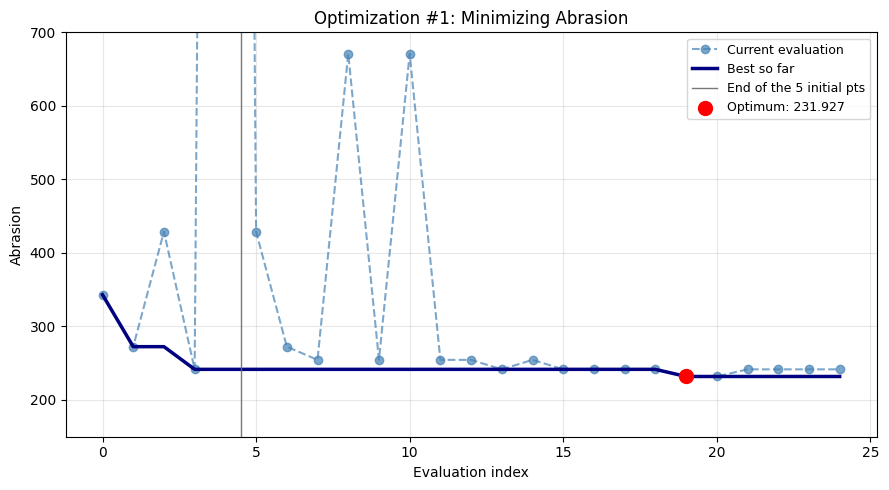

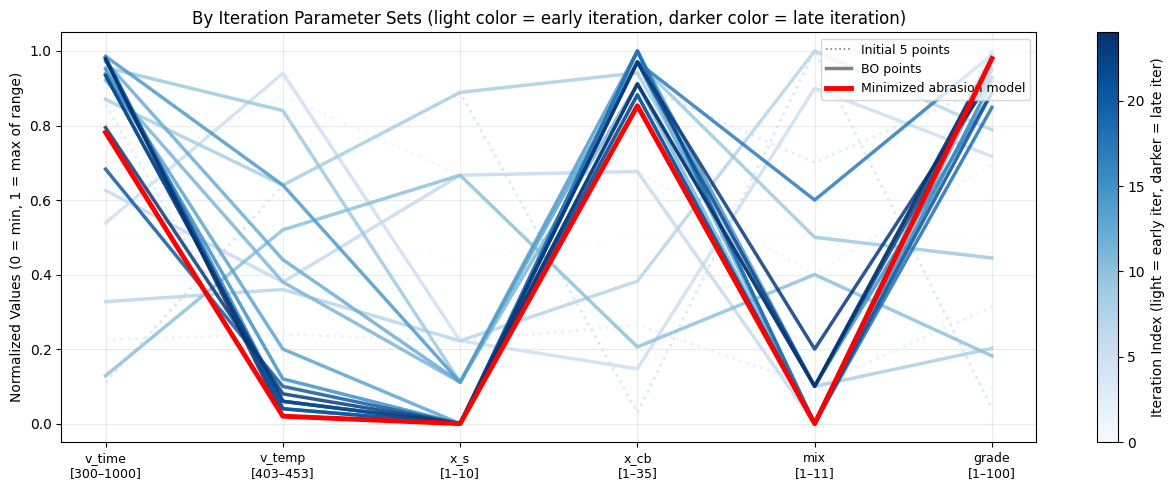

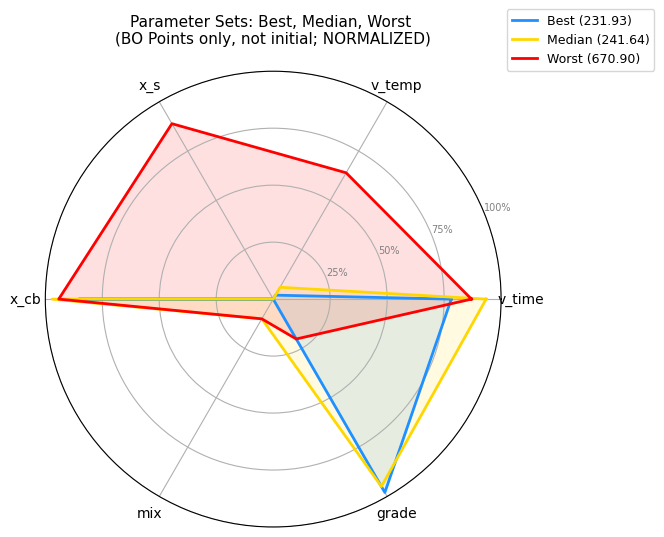

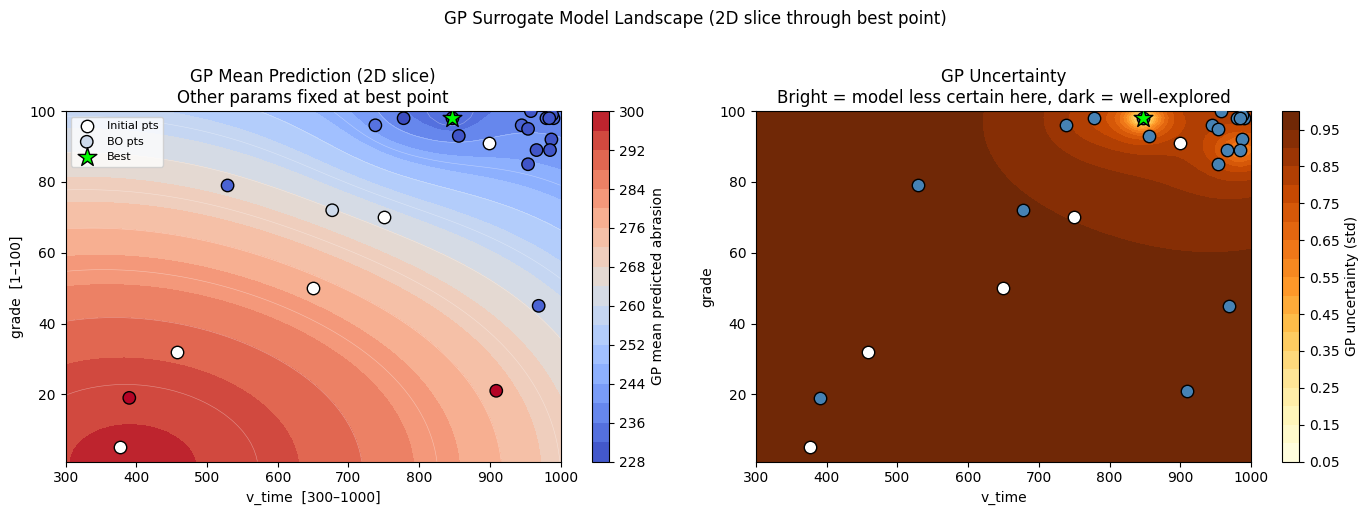

c:\Users\andyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 1600x600 with 0 Axes>

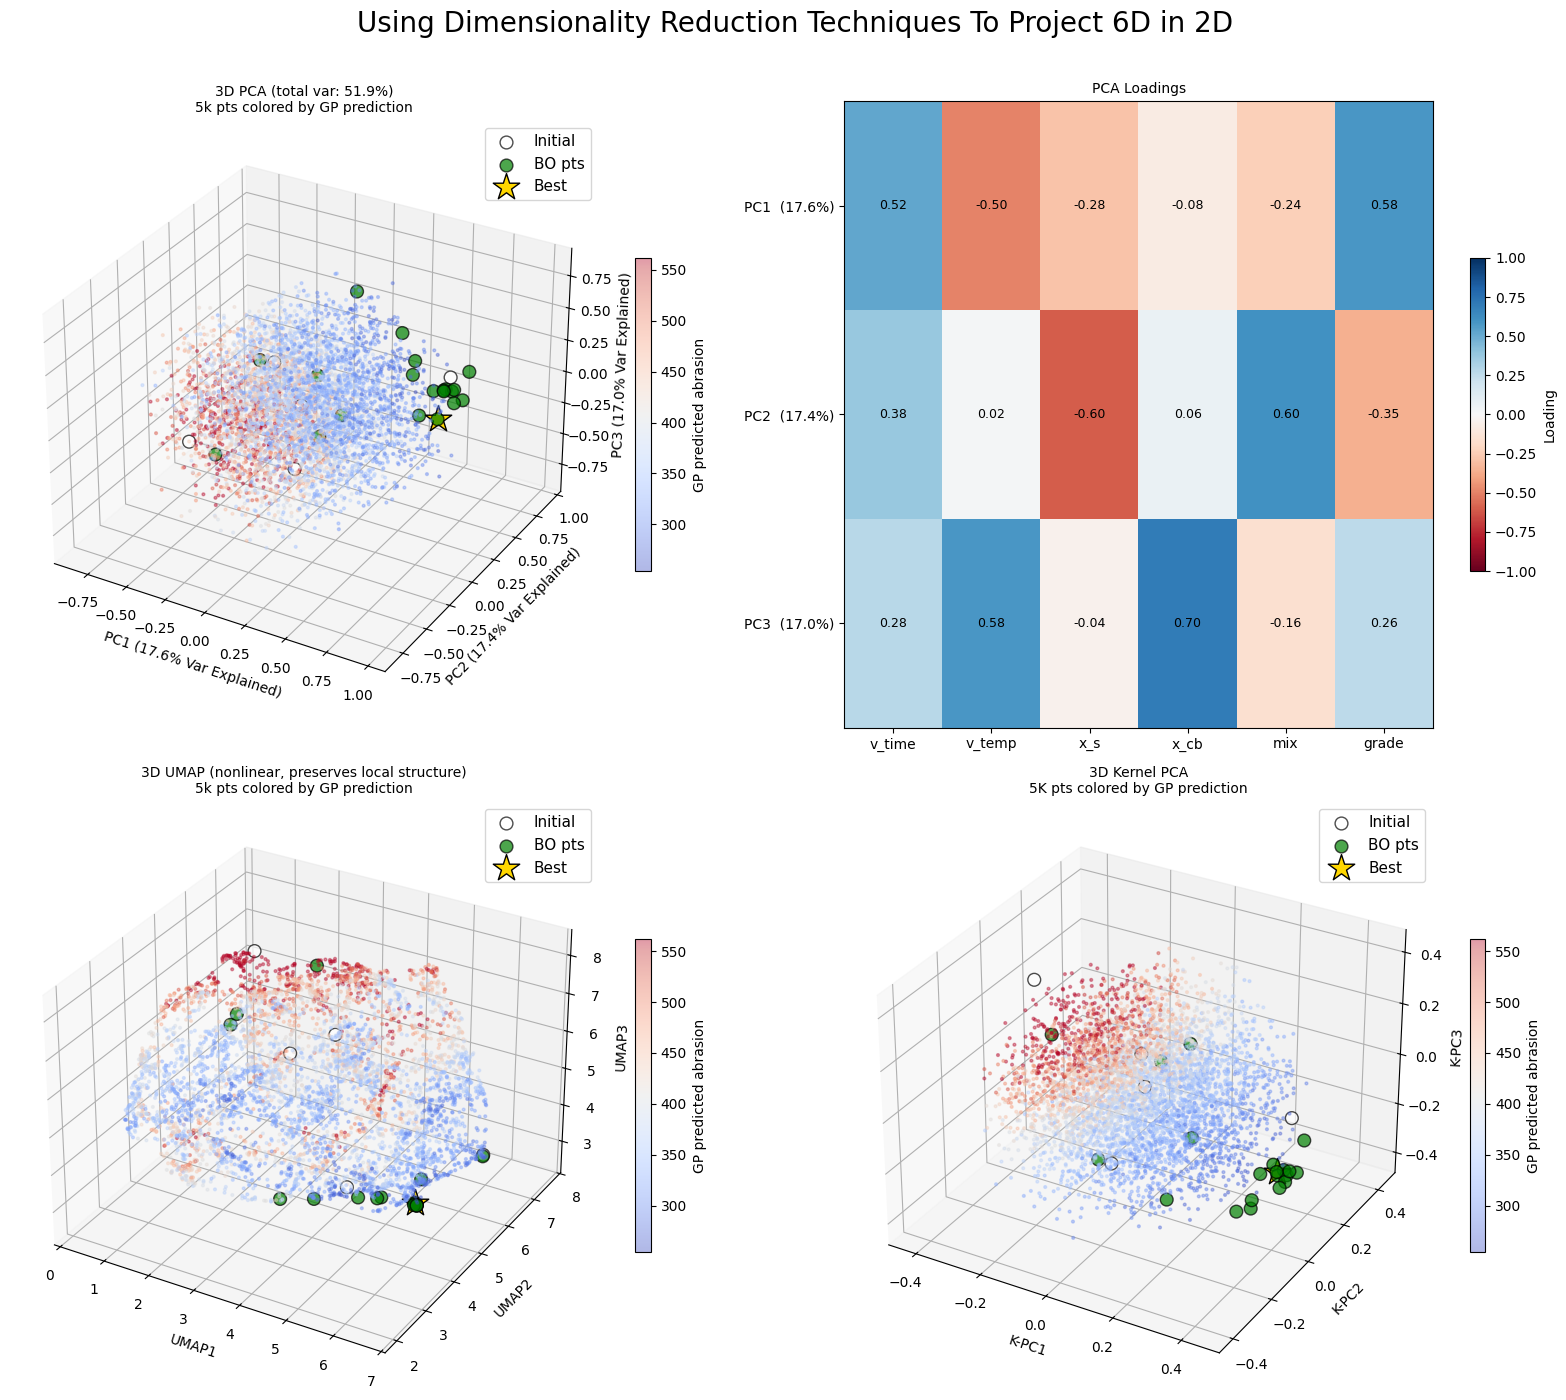


Eval   Type       v_time   v_temp      x_s     x_cb      mix    grade     abrasion     roll_res     dry_grip
--------------------------------------------------------------------------------------------------------------
0      init          650      428        5       18        6       50       343.13     0.177265   0.00305107
1      init          750      447        7       24        5       70       272.48     0.140409   0.00174503
2      init          458      415        3       10        2       32       428.94     0.310208   0.00734680
3      init          899      405        1       32        8       91       241.64     0.232879   0.00975282
4      init          377      435        9        2       11        5      5794.26     0.155936   0.00074382
5      BO-1          677      450        3        6       10       72       428.94     0.234512   0.00456897
6      BO-2          738      422        7       24        1       96       272.48     0.146928   0.00210018
7      BO-3     

In [145]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

n_total = X_train_A.shape[1]
abrasion_vals = -y_train_A # remove negation to plot
i_best = np.argmax(y_train_A)
X_normed = scaler.transform(X_train_A.T).T

good_vals = abrasion_vals[abrasion_vals < 1000]   # exclude the 5794 outlier
norm_abr  = mcolors.Normalize(vmin=good_vals.min(), vmax=good_vals.max())

######################################## PLOT #1 ########################################
fig, ax = plt.subplots(figsize=(9, 5))
best_curve = np.minimum.accumulate(abrasion_vals)
ax.plot(abrasion_vals, "o--", color="steelblue", label="Current evaluation", alpha=0.7)
ax.plot(best_curve, "-", color="navy", linewidth=2.5, label="Best so far")
ax.axvline(x = n_init - 0.5, color="dimgrey", linewidth = 1, alpha=0.9, label=f"End of the {n_init} initial pts")
ax.scatter(i_best, abrasion_vals[i_best], color="red", s=100, zorder=5, label=f"Optimum: {abrasion_vals[i_best]:.3f}")
ax.set_ylim(150, 700)
ax.set_xlabel("Evaluation index")
ax.set_ylabel("Abrasion")
ax.set_title("Optimization #1: Minimizing Abrasion")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

######################################## Plot #2 ########################################
fig, ax = plt.subplots(figsize=(13, 5))
iter_cmap = plt.cm.Blues
iter_norm  = mcolors.Normalize(vmin=0, vmax=n_total - 1)
sm = cm.ScalarMappable(cmap=iter_cmap, norm=iter_norm)
sm.set_array([])

for i in range(n_total):
    lw = 2.5 if i >= n_init else 2.0
    ls = "-"  if i >= n_init else ":"
    ax.plot(range(6), X_normed[:, i], color=iter_cmap(iter_norm(i)), linewidth=lw, linestyle=ls, alpha=0.85)
ax.plot(range(6), X_normed[:, i_best], color="red", linewidth=3.5, zorder=10, label=f"Best: abrasion = {abrasion_vals[i_best]:.2f}")
ax.set_xticks(range(6))
ax.set_xticklabels([f"{name}\n[{param_bounds[j,0]:.0f}–{param_bounds[j,1]:.0f}]" for j, name in enumerate(param_names)], fontsize=9)
ax.set_ylabel("Normalized Values (0 = min, 1 = max of range)")
ax.set_title("By Iteration Parameter Sets (light color = early iteration, darker color = late iteration)")

legend_els = [
    Line2D([0],[0], color="gray", lw=1.2, ls=":", label="Initial 5 points"),
    Line2D([0],[0], color="gray", lw=2.5, ls="-", label="BO points"),
    Line2D([0],[0], color="red",  lw=3.5, label="Minimized abrasion model"),
]
ax.legend(handles=legend_els, fontsize=9, loc="upper right")
plt.colorbar(sm, ax=ax, label="Iteration Index (light = early iter, darker = late iter)")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

######################################## PLOT #3 ########################################
BO_idx = np.arange(n_init, n_total)
abr_bo = abrasion_vals[BO_idx]
i_median = BO_idx[np.argsort(abr_bo)[len(abr_bo) // 2]]
i_worst = BO_idx[np.argmax(abr_bo)]

profiles = {f"Best ({abrasion_vals[i_best]:.2f})": X_normed[:, i_best],
    f"Median ({abrasion_vals[i_median]:.2f})": X_normed[:, i_median],
    f"Worst ({abrasion_vals[i_worst]:.2f})": X_normed[:, i_worst],}
radar_colors = ["dodgerblue", "gold", "red"]

angles  = np.linspace(0, 2 * np.pi, 6, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
for (label, vals), col in zip(profiles.items(), radar_colors):
    v = list(vals) + [vals[0]]
    ax.plot(angles, v, color=col, linewidth=2, label=label)
    ax.fill(angles, v, color=col, alpha=0.12)
ax.set_thetagrids(np.degrees(angles[:-1]), param_names, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="gray")
ax.set_title("Parameter Sets: Best, Median, Worst \n(BO Points only, not initial; NORMALIZED)", pad=20, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

# --- Plot 4: GP landscape — 2D slice (mean + uncertainty) ---
param_var           = np.var(X_train_A, axis=1)
ax1_idx, ax2_idx    = np.argsort(param_var)[-2:][::-1]
res                 = 60
p1_vals             = np.linspace(param_bounds[ax1_idx, 0], param_bounds[ax1_idx, 1], res)
p2_vals             = np.linspace(param_bounds[ax2_idx, 0], param_bounds[ax2_idx, 1], res)
P1, P2              = np.meshgrid(p1_vals, p2_vals)

X_grid              = np.tile(X_train_A[:, i_best], (res * res, 1)).T
X_grid[ax1_idx]     = P1.ravel()
X_grid[ax2_idx]     = P2.ravel()

gp_abrasion.fit(scaler.transform(X_train_A.T), y_train_A)
mu_grid, std_grid   = gp_abrasion.predict(scaler.transform(X_grid.T), return_std=True)
mu_abr              = (-mu_grid).reshape(res, res)
std_abr             = std_grid.reshape(res, res)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c0 = axes[0].contourf(P1, P2, mu_abr, levels=20, cmap="coolwarm")
axes[0].contour(P1, P2, mu_abr, levels=10, colors="white", linewidths=0.4, alpha=0.4)
plt.colorbar(c0, ax=axes[0], label="GP mean predicted abrasion")
axes[0].scatter(X_train_A[ax1_idx, :n_init], X_train_A[ax2_idx, :n_init],
                c="white", edgecolors="black", s=80, zorder=5, label="Initial pts")
axes[0].scatter(X_train_A[ax1_idx, n_init:], X_train_A[ax2_idx, n_init:],
                c=abrasion_vals[n_init:], cmap="coolwarm", norm=norm_abr,
                edgecolors="black", s=80, zorder=6, label="BO pts")
axes[0].scatter(X_train_A[ax1_idx, i_best], X_train_A[ax2_idx, i_best],
                c="lime", edgecolors="black", s=200, marker="*", zorder=7, label="Best")
axes[0].set_xlabel(f"{param_names[ax1_idx]}  [{param_bounds[ax1_idx,0]}–{param_bounds[ax1_idx,1]}]")
axes[0].set_ylabel(f"{param_names[ax2_idx]}  [{param_bounds[ax2_idx,0]}–{param_bounds[ax2_idx,1]}]")
axes[0].set_title("GP Mean Prediction (2D slice)\nOther params fixed at best point")
axes[0].legend(fontsize=8)

c1 = axes[1].contourf(P1, P2, std_abr, levels=20, cmap="YlOrBr")
plt.colorbar(c1, ax=axes[1], label="GP uncertainty (std)")
axes[1].scatter(X_train_A[ax1_idx, :n_init], X_train_A[ax2_idx, :n_init],
                c="white", edgecolors="black", s=80, zorder=5)
axes[1].scatter(X_train_A[ax1_idx, n_init:], X_train_A[ax2_idx, n_init:],
                c="steelblue", edgecolors="black", s=80, zorder=6)
axes[1].scatter(X_train_A[ax1_idx, i_best], X_train_A[ax2_idx, i_best],
                c="lime", edgecolors="black", s=200, marker="*", zorder=7)
axes[1].set_xlabel(param_names[ax1_idx])
axes[1].set_ylabel(param_names[ax2_idx])
axes[1].set_title("GP Uncertainty\nBright = model less certain here, dark = well-explored")

plt.suptitle("GP Surrogate Model Landscape (2D slice through best point)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

######################################## PLOT #5 ########################################
rng_viz = np.random.default_rng(999)
X_cand_viz = np.zeros((6, 5000))
for i in range(6): X_cand_viz[i] = rng_viz.uniform(param_bounds[i, 0], param_bounds[i, 1], 5000)
mu_cand, std_cand = gp_abrasion.predict(scaler.transform(X_cand_viz.T), return_std=True)
mu_cand_abr = -mu_cand

pca = PCA(n_components=3)
Z_all = pca.fit_transform(scaler.transform(np.hstack([X_cand_viz, X_train_A]).T))
Z_cand, Z_obs = Z_all[:5000], Z_all[5000:]

norm_mu = mcolors.Normalize(vmin=mu_cand_abr.min(), vmax=np.percentile(mu_cand_abr, 95))
ev = pca.explained_variance_ratio_ * 100
fig = plt.figure(figsize=(16, 6))


import umap
from sklearn.decomposition import KernelPCA
X_all_sc = scaler.transform(np.hstack([X_cand_viz, X_train_A]).T)

umap_reducer = umap.UMAP(n_components=3, random_state=42)
Z_all_umap = umap_reducer.fit_transform(X_all_sc)
Z_cand_umap, Z_obs_umap = Z_all_umap[:5000], Z_all_umap[5000:]

kpca = KernelPCA(n_components=3, kernel="rbf")
Z_all_kpca = kpca.fit_transform(X_all_sc)
Z_cand_kpca, Z_obs_kpca = Z_all_kpca[:5000], Z_all_kpca[5000:]

def plot_obs(ax, Z_obs, n_init, i_best):
    ax.scatter(Z_obs[:n_init,0], Z_obs[:n_init,1], Z_obs[:n_init,2], c="white", edgecolors="black", s=85, zorder=5, label="Initial", alpha=0.7)
    ax.scatter(Z_obs[n_init:,0], Z_obs[n_init:,1], Z_obs[n_init:,2], c="green",  edgecolors="black", s=85, zorder=6, label="BO pts", alpha=0.7)
    ax.scatter(Z_obs[i_best,0],  Z_obs[i_best,1],  Z_obs[i_best,2], c="gold",  edgecolors="black", s=400, marker="*", zorder=10000, label="Best")
fig = plt.figure(figsize=(16, 14))

##### PCA 3D Plot (1 PC per Cartesian direction)
ax0 = fig.add_subplot(221, projection="3d")
sc0 = ax0.scatter(Z_cand[:,0], Z_cand[:,1], Z_cand[:,2], c=mu_cand_abr, cmap="coolwarm", norm=norm_mu, s=4, alpha=0.4)
plot_obs(ax0, Z_obs, n_init, i_best)
fig.colorbar(sc0, ax=ax0, label="GP predicted abrasion", shrink=0.5)
ax0.set_xlabel(f"PC1 ({ev[0]:.1f}% Var Explained)")
ax0.set_ylabel(f"PC2 ({ev[1]:.1f}% Var Explained)")
ax0.set_zlabel(f"PC3 ({ev[2]:.1f}% Var Explained)")
ax0.set_title(f"3D PCA (total var: {ev.sum():.1f}%)\n5k pts colored by GP prediction", fontsize=10)
ax0.legend(fontsize=11)

##### PCA Loadings Plot
ax1 = fig.add_subplot(222)
loadings = pca.components_
im = ax1.imshow(loadings, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax1.set_xticks(range(6))
ax1.set_xticklabels(param_names, fontsize=10)
ax1.set_yticks(range(3))
ax1.set_yticklabels([f"PC{i+1}  ({ev[i]:.1f}%)" for i in range(3)], fontsize=10)
ax1.set_title("PCA Loadings", fontsize=10)
for r in range(3):
    for c in range(6):
        ax1.text(c, r, f"{loadings[r,c]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax1, label="Loading", shrink=0.5)

##### UMAP 3D Plot
ax2 = fig.add_subplot(223, projection="3d")
sc2 = ax2.scatter(Z_cand_umap[:,0], Z_cand_umap[:,1], Z_cand_umap[:,2], c=mu_cand_abr, cmap="coolwarm", norm=norm_mu, s=4, alpha=0.4)
plot_obs(ax2, Z_obs_umap, n_init, i_best)
fig.colorbar(sc2, ax=ax2, label="GP predicted abrasion", shrink=0.5)
ax2.set_xlabel("UMAP1")
ax2.set_ylabel("UMAP2")
ax2.set_zlabel("UMAP3")
ax2.set_title("3D UMAP (nonlinear, preserves local structure)\n5k pts colored by GP prediction", fontsize=10)
ax2.legend(fontsize=11)

##### Kernal PCA 3D Plot (nonlinear PCA, each PC is infinite dimensions, can't make heatmap)
ax3 = fig.add_subplot(224, projection="3d")
sc3 = ax3.scatter(Z_cand_kpca[:,0], Z_cand_kpca[:,1], Z_cand_kpca[:,2], c=mu_cand_abr, cmap="coolwarm", norm=norm_mu, s=4, alpha=0.4)
plot_obs(ax3, Z_obs_kpca, n_init, i_best)
fig.colorbar(sc3, ax=ax3, label="GP predicted abrasion", shrink=0.5)
ax3.set_xlabel("K-PC1")
ax3.set_ylabel("K-PC2")
ax3.set_zlabel("K-PC3")
ax3.set_title("3D Kernel PCA\n5K pts colored by GP prediction", fontsize=10)
ax3.legend(fontsize=11)

plt.suptitle("Using Dimensionality Reduction Techniques To Project 6D in 2D", fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"\n{'Eval':<6} {'Type':<8}", end="")
for name in param_names:
    print(f" {name:>8}", end="")
print(f" {'abrasion':>12} {'roll_res':>12} {'dry_grip':>12}")
print("-" * 110)
for i in range(n_total):
    tag = "init" if i < n_init else f"BO-{i-n_init+1}"
    print(f"{i:<6} {tag:<8}", end="")
    for j in range(6):
        print(f" {X_train_A[j,i]:>8.0f}", end="")
    print(f" {abrasion_vals[i]:>12.2f} "
          f"{all_outputs_A['rolling_resistance'][i]:>12.6f} "
          f"{all_outputs_A['dry_grip'][i]:>12.8f}")

### Optimization A - Summary

In [ ]:
print("Evaluations (Optimization A - Minimize Abrasion):")
for i in range(X_train_A.shape[1]):
    print(f"  Point {i}: {dict(zip(param_names, X_train_A[:, i]))} --- abrasion = {-y_train_A[i]:.4f}")

i_best_A = np.argmax(y_train_A)
X_best_A = X_train_A[:, i_best_A]
print(f"\nBest point: {dict(zip(param_names, X_best_A))}")
print(f"Best abrasion: {-y_train_A[i_best_A]:.4f}")
print(f"Total evaluations: {X_train_A.shape[1]} (including {n_init} initial points)")

print("\nAll metrics for best abrasion point:")
for name in output_names:
    print(f"  {name}: {all_outputs_A[name][i_best_A]:.6f}")

Evaluations (Optimization A - Minimize Abrasion):
  Point 0: {'v_time': np.float64(650.0), 'v_temp': np.float64(428.0), 'x_s': np.float64(5.0), 'x_cb': np.float64(18.0), 'mix': np.float64(6.0), 'grade': np.float64(50.0)} --- abrasion = 343.1310
  Point 1: {'v_time': np.float64(750.0), 'v_temp': np.float64(447.0), 'x_s': np.float64(7.0), 'x_cb': np.float64(24.0), 'mix': np.float64(5.0), 'grade': np.float64(70.0)} --- abrasion = 272.4794
  Point 2: {'v_time': np.float64(458.0), 'v_temp': np.float64(415.0), 'x_s': np.float64(3.0), 'x_cb': np.float64(10.0), 'mix': np.float64(2.0), 'grade': np.float64(32.0)} --- abrasion = 428.9430
  Point 3: {'v_time': np.float64(899.0), 'v_temp': np.float64(405.0), 'x_s': np.float64(1.0), 'x_cb': np.float64(32.0), 'mix': np.float64(8.0), 'grade': np.float64(91.0)} --- abrasion = 241.6364
  Point 4: {'v_time': np.float64(377.0), 'v_temp': np.float64(435.0), 'x_s': np.float64(9.0), 'x_cb': np.float64(2.0), 'mix': np.float64(11.0), 'grade': np.float64(5.0)} 

---
## Optimization B: Minimize Rolling Resistance
Same 5 initial points, but new optimization.

In [79]:
from sklearn.gaussian_process.kernels import Matern

gp_rolling = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=10, normalize_y=True)
X_train_B = X_train.copy()
y_train_B = -all_outputs["rolling_resistance"].copy() # negate
all_outputs_B = {name: all_outputs[name].copy() for name in output_names}

i_best = np.argmax(y_train_B)
print(f"Current best rolling resistance: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

Current best rolling resistance: 0.140409 (Point 2)


### Opt2: Iteration #1

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=55)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 723
---v_temp: 447
---x_s: 7
---x_cb: 23
---mix: 5
---grade: 74


In [81]:
new_RR_Iter1 = {
    "material_cost": 1061.1454422,
    "heating_cost": 14.731200000000001,
    "mixing_cost": 24.2685,
    "sound_damping": 0.06817709624337401,
    "rolling_resistance": 0.1409693100658347,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0017889192262328137,
    "wet_grip": 6.93979621
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter1["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter1[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter1['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.140969
Current best rolling res value: 0.140409 (Point 2)


### Opt2: Iteration #2

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=56)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 697
---v_temp: 448
---x_s: 8
---x_cb: 18
---mix: 9
---grade: 52


In [83]:
new_RR_Iter2 = {
    "material_cost": 679.1461496,
    "heating_cost": 14.456500000000002,
    "mixing_cost": 43.6833,
    "sound_damping": 0.07510479740501141,
    "rolling_resistance": 0.13105614514713404,
    "abrasion": 428.94298432566035,
    "dry_grip": 0.0013391471790120974,
    "wet_grip": 4.9234884899999996
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter2["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter2[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter2['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.131056
Current best rolling res value: 0.131056 (Point 7)


### Opt2: Iteration #3

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=57)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 518
---v_temp: 444
---x_s: 10
---x_cb: 32
---mix: 10
---grade: 65


In [87]:
new_RR_Iter3 = {
    "material_cost": 1245.3820079999998,
    "heating_cost": 11.5338,
    "mixing_cost": 48.537,
    "sound_damping": 0.06114803763518931,
    "rolling_resistance": 0.12613710217513907,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0011983503077240111,
    "wet_grip": 8.47221017
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter3["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter3[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter3['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.126137
Current best rolling res value: 0.126137 (Point 8)


### Opt2: Iteration #4

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=58)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 566
---v_temp: 443
---x_s: 9
---x_cb: 33
---mix: 11
---grade: 4


In [90]:
new_RR_Iter4 = {
    "material_cost": 235.0788852,
    "heating_cost": 11.258000000000001,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.09738519404440563,
    "rolling_resistance": 0.12937513973565967,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0005017301188093229,
    "wet_grip": 1.971748395
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter4["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter4[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter4['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.129375
Current best rolling res value: 0.126137 (Point 8)


### Opt2: Iteration #5

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=59)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 969
---v_temp: 451
---x_s: 10
---x_cb: 35
---mix: 11
---grade: 29


In [92]:
new_RR_Iter5 = {
    "material_cost": 689.3288415,
    "heating_cost": 18.781200000000002,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0662054964503036,
    "rolling_resistance": 0.11128230640510432,
    "abrasion": 343.1309573700778,
    "dry_grip": 0.0007220376466623565,
    "wet_grip": 6.746642879999999
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter5["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter5[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter5['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.111282
Current best rolling res value: 0.111282 (Point 10)


### Opt2: Iteration #6

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=60)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 947
---v_temp: 432
---x_s: 10
---x_cb: 23
---mix: 11
---grade: 47


In [94]:
new_RR_Iter6 = {
    "material_cost": 748.8667041,
    "heating_cost": 16.0863,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.06576335539436724,
    "rolling_resistance": 0.11460952075560167,
    "abrasion": 343.1309573700778,
    "dry_grip": 0.0009396597777835468,
    "wet_grip": 6.030113699999999
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter6["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter6[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter6['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.114610
Current best rolling res value: 0.111282 (Point 10)


### Opt2: Iteration #7

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=61)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 991
---v_temp: 444
---x_s: 10
---x_cb: 26
---mix: 10
---grade: 95


In [96]:
new_RR_Iter7 = {
    "material_cost": 1459.4115270000002,
    "heating_cost": 18.2031,
    "mixing_cost": 48.537,
    "sound_damping": 0.057734727769937474,
    "rolling_resistance": 0.1158835302707438,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0010016564189061087,
    "wet_grip": 8.11067075
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter7["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter7[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter7['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.115884
Current best rolling res value: 0.111282 (Point 10)


### Opt2: Iteration #8

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=62)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 942
---v_temp: 441
---x_s: 10
---x_cb: 4
---mix: 10
---grade: 95


In [98]:
new_RR_Iter8 = {
    "material_cost": 427.38735799999995,
    "heating_cost": 17.1396,
    "mixing_cost": 48.537,
    "sound_damping": 0.07884943138155623,
    "rolling_resistance": 0.10772313504733055,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0007012990452608617,
    "wet_grip": 2.75472731
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter8["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter8[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter8['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.107723
Current best rolling res value: 0.107723 (Point 13)


### Opt2: Iteration #9

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=63)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 981
---v_temp: 417
---x_s: 10
---x_cb: 1
---mix: 11
---grade: 90


In [100]:
new_RR_Iter9 = {
    "material_cost": 284.076109,
    "heating_cost": 14.603400000000002,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.08805479322691845,
    "rolling_resistance": 0.10897654849216454,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0005107689798958431,
    "wet_grip": 1.598656997
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter9["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter9[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter9['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.108977
Current best rolling res value: 0.107723 (Point 13)


### Opt2: Iteration #10

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=64)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 988
---v_temp: 449
---x_s: 10
---x_cb: 8
---mix: 11
---grade: 29


In [102]:
new_RR_Iter10 = {
    "material_cost": 342.5082552,
    "heating_cost": 18.8048,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.08467411145390447,
    "rolling_resistance": 0.1035925408135647,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0004522895329770523,
    "wet_grip": 1.827301604
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter10["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter10[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter10['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.103593
Current best rolling res value: 0.103593 (Point 15)


### Opt2: Iteration #11

In [ ]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=65)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 967
---v_temp: 431
---x_s: 10
---x_cb: 1
---mix: 11
---grade: 60


In [104]:
new_RR_Iter11 = {
    "material_cost": 268.592026,
    "heating_cost": 16.2176,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0886804055144444,
    "rolling_resistance": 0.10491538453456357,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00039931940614586697,
    "wet_grip": 1.3158819080000002
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter11["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter11[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter11['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.104915
Current best rolling res value: 0.103593 (Point 15)


### Opt2: Iteration #12

In [108]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=66)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 966
---v_temp: 451
---x_s: 10
---x_cb: 22
---mix: 11
---grade: 3


In [112]:
new_RR_Iter12 = {
    "material_cost": 227.1113026,
    "heating_cost": 18.736800000000002,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0881245146066701,
    "rolling_resistance": 0.10182409126740166,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002853741299671511,
    "wet_grip": 1.458163076
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter12["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter12[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter12['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101824
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #13

In [113]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=67)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 998
---v_temp: 442
---x_s: 10
---x_cb: 21
---mix: 10
---grade: 4


In [114]:
new_RR_Iter13 = {
    "material_cost": 238.52449239999999,
    "heating_cost": 18.0422,
    "mixing_cost": 48.537,
    "sound_damping": 0.08861214580349876,
    "rolling_resistance": 0.10230525291968406,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00028567747102836526,
    "wet_grip": 1.403702199
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter13["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter13[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter13['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.102305
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #14

In [115]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=68)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 931
---v_temp: 443
---x_s: 10
---x_cb: 2
---mix: 11
---grade: 1


In [116]:
new_RR_Iter14 = {
    "material_cost": 236.5333922,
    "heating_cost": 17.234,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.09116214691985933,
    "rolling_resistance": 0.10208568439304828,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002638351708526379,
    "wet_grip": 0.8833097859999999
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter14["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter14[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter14['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.102086
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #15

In [117]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=69)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 984
---v_temp: 445
---x_s: 9
---x_cb: 11
---mix: 11
---grade: 2


In [118]:
new_RR_Iter15 = {
    "material_cost": 225.0041942,
    "heating_cost": 18.2328,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0940407895965241,
    "rolling_resistance": 0.11084260674700923,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00033388132360750045,
    "wet_grip": 1.08400099
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter15["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter15[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter15['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.110843
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #16

In [119]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=70)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 978
---v_temp: 450
---x_s: 10
---x_cb: 5
---mix: 5
---grade: 18


In [120]:
new_RR_Iter16 = {
    "material_cost": 275.585149,
    "heating_cost": 18.7866,
    "mixing_cost": 24.2685,
    "sound_damping": 0.08888749033597639,
    "rolling_resistance": 0.10166656513226409,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0003137195157940648,
    "wet_grip": 1.148665995
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter16["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter16[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter16['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101667
Current best rolling res value: 0.101667 (Point 21)


### Opt2: Iteration #17

In [121]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=71)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 998
---v_temp: 449
---x_s: 10
---x_cb: 1
---mix: 8
---grade: 27


In [125]:
new_RR_Iter17 = {
    "material_cost": 251.55953469999997,
    "heating_cost": 18.9508,
    "mixing_cost": 38.8296,
    "sound_damping": 0.08984798697808313,
    "rolling_resistance": 0.10122245910343115,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00028741218255784527,
    "wet_grip": 0.9798125179999999
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter17["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter17[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter17['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101222
Current best rolling res value: 0.101222 (Point 22)


### Opt2: Iteration #18

In [126]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=72)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 999
---v_temp: 450
---x_s: 10
---x_cb: 21
---mix: 5
---grade: 6


In [133]:
new_RR_Iter18 = {
    "material_cost": 260.2022086,
    "heating_cost": 19.0953,
    "mixing_cost": 24.2685,
    "sound_damping": 0.08831886688707667,
    "rolling_resistance": 0.10159487228664324,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002807983550182083,
    "wet_grip": 1.39826458
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter18["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter18[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter18['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101595
Current best rolling res value: 0.101222 (Point 22)


### Opt2: Iteration #19

In [134]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=73)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 998
---v_temp: 450
---x_s: 10
---x_cb: 5
---mix: 6
---grade: 4


In [137]:
new_RR_Iter19 = {
    "material_cost": 239.455622,
    "heating_cost": 19.0806,
    "mixing_cost": 29.1222,
    "sound_damping": 0.090275680357172,
    "rolling_resistance": 0.10090499193122549,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002602584908443559,
    "wet_grip": 0.9389147899999999
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter19["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter19[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter19['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.100905
Current best rolling res value: 0.100905 (Point 24)


### Opt2: Iteration #20

In [138]:
x_next_B = NextPoint(gp_rolling, X_train_B, y_train_B, seed=74)
print("New parameter set:")
for name, val in zip(param_names, x_next_B): print(f"---{name}: {val:.0f}")

New parameter set:
---v_time: 997
---v_temp: 429
---x_s: 10
---x_cb: 13
---mix: 6
---grade: 79


In [146]:
new_RR_Iter19 = {
    "material_cost": 742.2227547,
    "heating_cost": 16.342200000000002,
    "mixing_cost": 29.1222,
    "sound_damping": 0.06769663539435551,
    "rolling_resistance": 0.11370106616327533,
    "abrasion": 428.94298432566035,
    "dry_grip": 0.000990616349985573,
    "wet_grip": 5.0646483899999994
}

X_train_B = np.append(X_train_B, x_next_B.reshape(6, 1), axis=-1)
y_train_B = np.append(y_train_B, -new_RR_Iter19["rolling_resistance"])
for name in output_names: all_outputs_B[name] = np.append(all_outputs_B[name], new_RR_Iter19[name])

i_best = np.argmax(y_train_B)
print(f"New rolling res: {new_RR_Iter19['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-y_train_B[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.113701
Current best rolling res value: 0.100905 (Point 24)


### Optimization B - Summary

Evaluations (Optimization B - Minimize Rolling Resistance):
  Point 0: {'v_time': np.float64(650.0), 'v_temp': np.float64(428.0), 'x_s': np.float64(5.0), 'x_cb': np.float64(18.0), 'mix': np.float64(6.0), 'grade': np.float64(50.0)} --- rolling_res = 0.177265
  Point 1: {'v_time': np.float64(750.0), 'v_temp': np.float64(447.0), 'x_s': np.float64(7.0), 'x_cb': np.float64(24.0), 'mix': np.float64(5.0), 'grade': np.float64(70.0)} --- rolling_res = 0.140409
  Point 2: {'v_time': np.float64(458.0), 'v_temp': np.float64(415.0), 'x_s': np.float64(3.0), 'x_cb': np.float64(10.0), 'mix': np.float64(2.0), 'grade': np.float64(32.0)} --- rolling_res = 0.310208
  Point 3: {'v_time': np.float64(899.0), 'v_temp': np.float64(405.0), 'x_s': np.float64(1.0), 'x_cb': np.float64(32.0), 'mix': np.float64(8.0), 'grade': np.float64(91.0)} --- rolling_res = 0.232879
  Point 4: {'v_time': np.float64(377.0), 'v_temp': np.float64(435.0), 'x_s': np.float64(9.0), 'x_cb': np.float64(2.0), 'mix': np.float64(11.0), 'gra

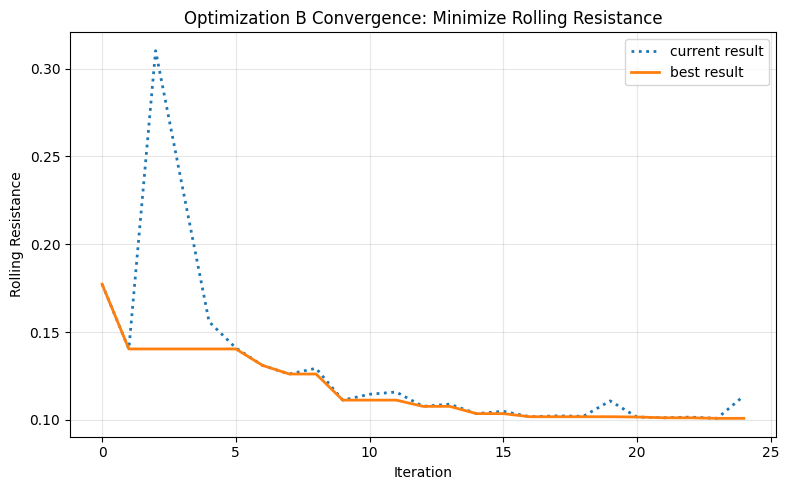

In [147]:
print("Evaluations (Optimization B - Minimize Rolling Resistance):")
for i in range(X_train_B.shape[1]):
    print(f"  Point {i}: {dict(zip(param_names, X_train_B[:, i]))} --- rolling_res = {-y_train_B[i]:.6f}")

i_best_B = np.argmax(y_train_B)
X_best_B = X_train_B[:, i_best_B]
print(f"\nBest point: {dict(zip(param_names, X_best_B))}")
print(f"Best rolling resistance: {-y_train_B[i_best_B]:.6f}")
print(f"Total evaluations: {X_train_B.shape[1]} (including {n_init} initial points)")

print("\nAll metrics for best rolling resistance point:")
for name in output_names:
    print(f"  {name}: {all_outputs_B[name][i_best_B]:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(-y_train_B, ":", label="current result", linewidth=2)
ax.plot(np.minimum.accumulate(-y_train_B), label="best result", linewidth=2)
ax.set_ylabel("Rolling Resistance")
ax.set_xlabel("Iteration")
ax.set_title("Optimization B Convergence: Minimize Rolling Resistance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

---
## Comparison: Baseline vs Optimized Compounds

In [148]:
baseline_idx = 0

print(f"{'Metric':<25} {'Baseline':>15} {'Durability (A)':>20} {'Thermal Eff (B)':>20}")
print("-" * 80)
for name in output_names:
    base_val = all_outputs_A[name][baseline_idx]
    opt_a_val = all_outputs_A[name][i_best_A]
    opt_b_val = all_outputs_B[name][i_best_B]
    print(f"{name:<25} {base_val:>15.6f} {opt_a_val:>20.6f} {opt_b_val:>20.6f}")

print(f"\n{'Parameter':<25} {'Baseline':>15} {'Durability (A)':>20} {'Thermal Eff (B)':>20}")
print("-" * 80)
for j, name in enumerate(param_names):
    print(f"{name:<25} {X_train[j, 0]:>15.1f} {X_best_A[j]:>20.1f} {X_best_B[j]:>20.1f}")

Metric                           Baseline       Durability (A)      Thermal Eff (B)
--------------------------------------------------------------------------------
material_cost                  652.323470          1668.779194           239.455622
heating_cost                    11.875000            11.584700            19.080600
mixing_cost                     29.122200             4.853700            29.122200
sound_damping                    0.086353             0.079291             0.090276
rolling_resistance               0.177265             0.233961             0.100905
abrasion                       343.130957           231.927121          5794.259220
dry_grip                         0.003051             0.010291             0.000260
wet_grip                         4.792315             8.565412             0.938915

Parameter                        Baseline       Durability (A)      Thermal Eff (B)
------------------------------------------------------------------------------

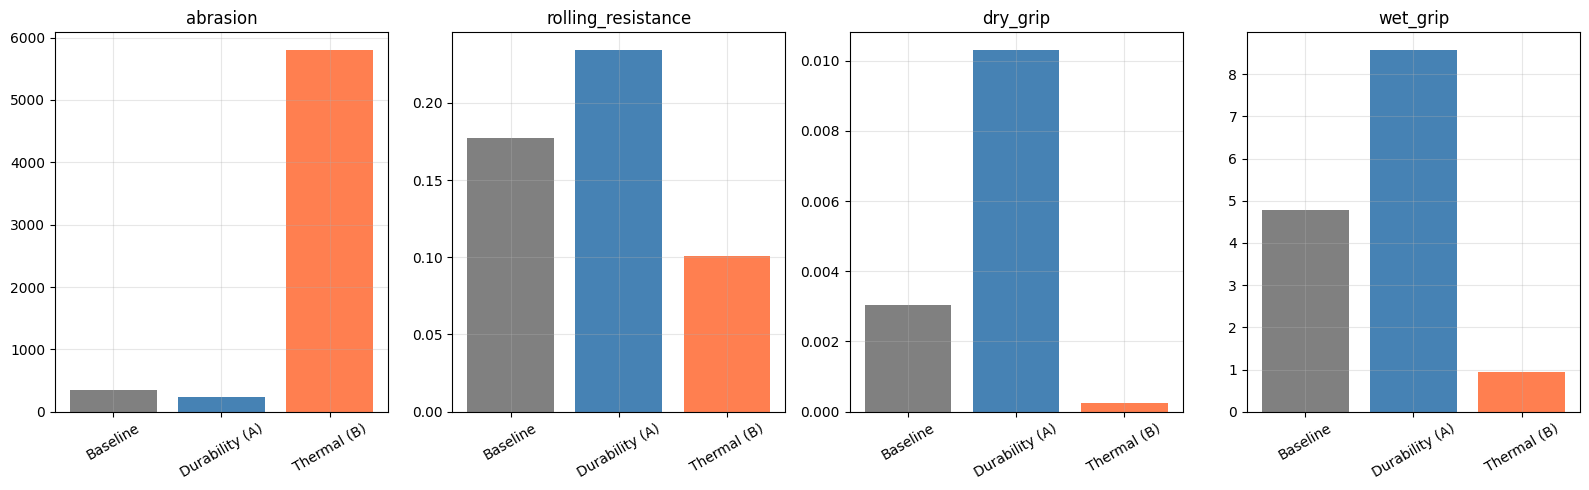

In [149]:
key_metrics = ["abrasion", "rolling_resistance", "dry_grip", "wet_grip"]
baseline_vals = [all_outputs_A[m][baseline_idx] for m in key_metrics]
opt_a_vals = [all_outputs_A[m][i_best_A] for m in key_metrics]
opt_b_vals = [all_outputs_B[m][i_best_B] for m in key_metrics]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for idx, metric in enumerate(key_metrics):
    vals = [baseline_vals[idx], opt_a_vals[idx], opt_b_vals[idx]]
    colors = ['gray', 'steelblue', 'coral']
    labels = ['Baseline', 'Durability (A)', 'Thermal (B)']
    axes[idx].bar(labels, vals, color=colors)
    axes[idx].set_title(metric)
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()